# 03 包络分析（共振解调）

**本节目标**：以外圈故障为例，完整走一遍共振解调流程，理解每一步的必要性：

1. 原始信号频谱——故障信息为什么被淹没；
2. 带通滤波——锁定结构共振频带；
3. Hilbert 变换取包络——把高频共振的"幅值起伏"解调出来；
4. 包络谱——在低频谱线上直接读出故障特征频率 BPFO ≈ 107.4 Hz。

**原理**（详见 [docs/04 包络分析与共振解调](../docs/04_envelope_analysis.md)）

故障冲击激发的高频共振响应 $h(t)$ 本身不含故障频率信息，信息藏在**冲击的重复间隔**
（即共振响应幅值的起伏）里。包络分析先对共振频带做带通滤波，再用 Hilbert 变换构造
解析信号并取模：

$$z(t) = x(t) + j\,\mathcal{H}[x(t)], \qquad a(t) = |z(t)|$$

包络 $a(t)$ 是一个以故障特征频率为基频的低频信号，对它做 FFT 得到**包络谱**，
故障频率及其谐波就显现为清晰谱线。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from bearing_fault import (Bearing, BearingSimulator, amplitude_spectrum,
                           analytic_envelope, bandpass, envelope_analysis,
                           envelope_spectrum)
from bearing_fault.plotting import plot_spectrum, plot_waveform

FS, RPM, DURATION, SEED = 12000, 1797, 3.0, 42
BPFO = Bearing.sk6205().characteristic_frequencies(RPM / 60.0)["outer"]
print(f"外圈故障理论特征频率 BPFO = {BPFO:.2f} Hz")

x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal("outer", snr_db=-6.0)
t = np.arange(x.size) / FS

外圈故障理论特征频率 BPFO = 107.36 Hz


## 第 1 步：原始信号频谱——故障信息被淹没

直接对原始信号做 FFT：能量集中在 4 kHz 结构共振峰附近，
低频段的转频和故障特征频率完全淹没在噪声里。只看这张谱，无法诊断任何故障。

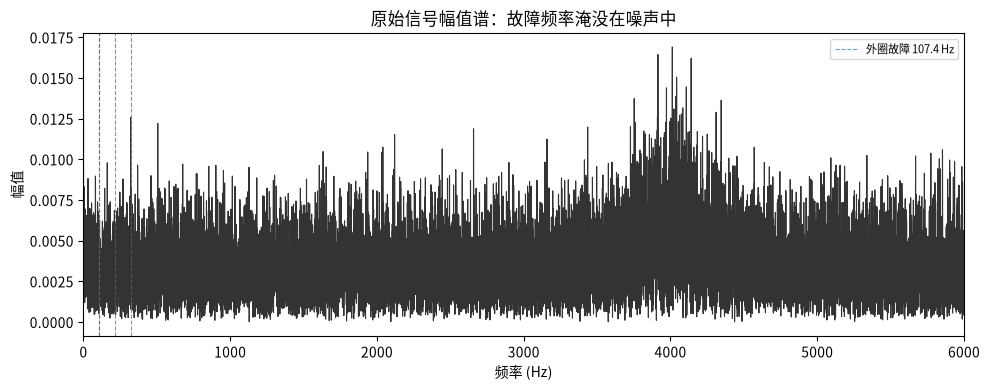

In [2]:
freqs, amps = amplitude_spectrum(x, FS)
plot_spectrum(freqs, amps, char_freqs={"outer": BPFO},
              xlim=(0, 6000), title="原始信号幅值谱：故障频率淹没在噪声中")
plt.show()

## 第 2 步：带通滤波——锁定共振频带

故障冲击的能量集中在结构共振频率（4 kHz）附近。用带通滤波器取出
2–5.4 kHz 频段（缺省自动频带 $f_s/6$ 到 $0.45 f_s$），
滤除低频转频分量和带外噪声。滤波后的信号里，周期性冲击已经隐约可见。

解调频带：2000 – 5400 Hz


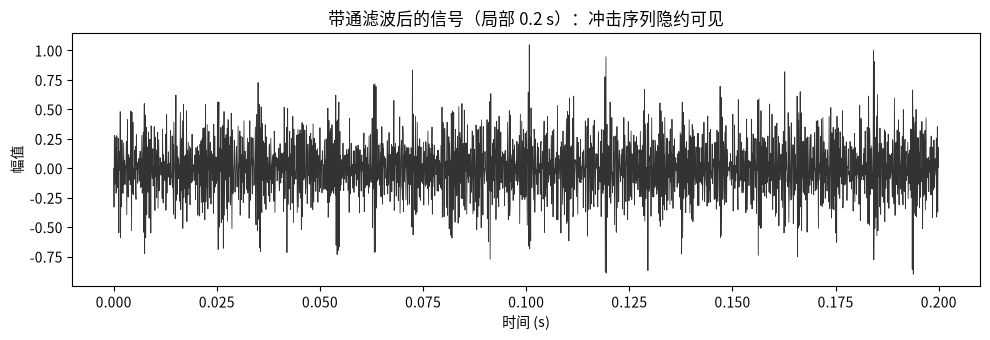

In [3]:
band = (FS / 6, 0.45 * FS)
filtered = bandpass(x, FS, band[0], band[1])
print(f"解调频带：{band[0]:.0f} – {band[1]:.0f} Hz")
plot_waveform(t, filtered, t_range=(0, 0.2),
             title="带通滤波后的信号（局部 0.2 s）：冲击序列隐约可见")
plt.show()

## 第 3 步：Hilbert 变换取包络

对滤波信号构造解析信号并取模，得到包络 $a(t)=|z(t)|$。
包络把 4 kHz 载波"拆掉"，只留下幅值起伏——即冲击重复的节奏（≈ 9.3 ms 一次）。

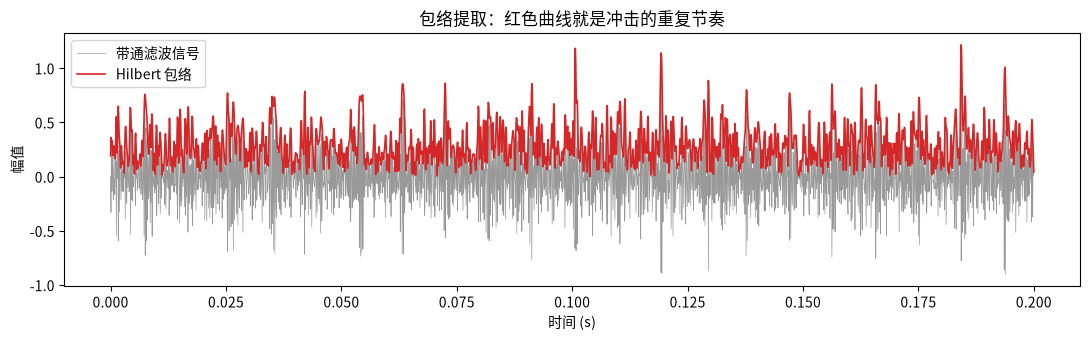

In [4]:
env = analytic_envelope(filtered)

fig, ax = plt.subplots(figsize=(11, 3.5))
mask = (t >= 0) & (t <= 0.2)
ax.plot(t[mask], filtered[mask], lw=0.5, color="0.6", label="带通滤波信号")
ax.plot(t[mask], env[mask], lw=1.2, color="tab:red", label="Hilbert 包络")
ax.set_xlabel("时间 (s)")
ax.set_ylabel("幅值")
ax.set_title("包络提取：红色曲线就是冲击的重复节奏")
ax.legend()
fig.tight_layout()
plt.show()

## 第 4 步：包络谱——BPFO 及其谐波清晰可见

包络去直流后做 FFT。谱上在 **BPFO ≈ 107.4 Hz 及其 2、3 次谐波**处出现明显谱线，
与理论频率（虚线）精确吻合——这就是外圈故障的确诊证据。

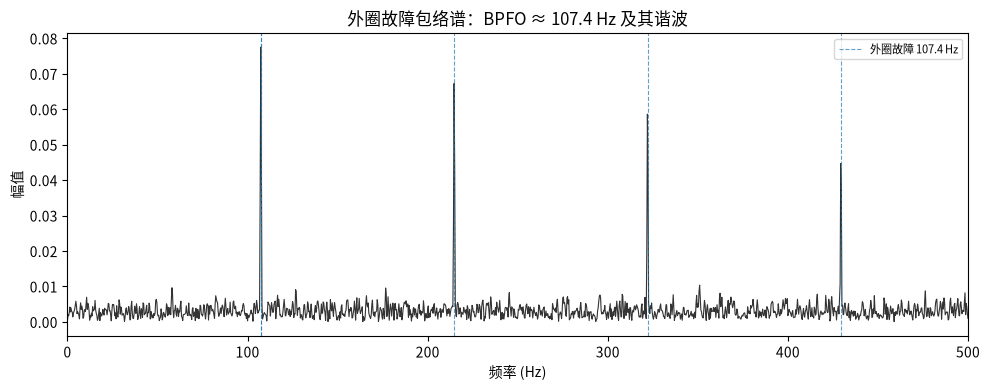

100–115 Hz 区间内最强峰：107.33 Hz（理论 BPFO = 107.36 Hz，相对误差 0.03%）


In [5]:
env_freqs, env_amps = envelope_spectrum(env, FS)
plot_spectrum(env_freqs, env_amps, char_freqs={"outer": BPFO},
              xlim=(0, 500), harmonics=4,
              title="外圈故障包络谱：BPFO ≈ 107.4 Hz 及其谐波")
plt.show()

# 定量验证：100–115 Hz 区间内的谱峰位置
sel = (env_freqs >= 100) & (env_freqs <= 115)
f_peak = env_freqs[sel][np.argmax(env_amps[sel])]
print(f"100–115 Hz 区间内最强峰：{f_peak:.2f} Hz（理论 BPFO = {BPFO:.2f} Hz，"
      f"相对误差 {abs(f_peak - BPFO) / BPFO * 100:.2f}%）")

## 对比：健康信号的包络谱

同样的流程用在健康信号上，包络谱上没有任何显著谱线——
只有噪声地板。有无特征谱线正是第 06 节自动判别流程的依据。

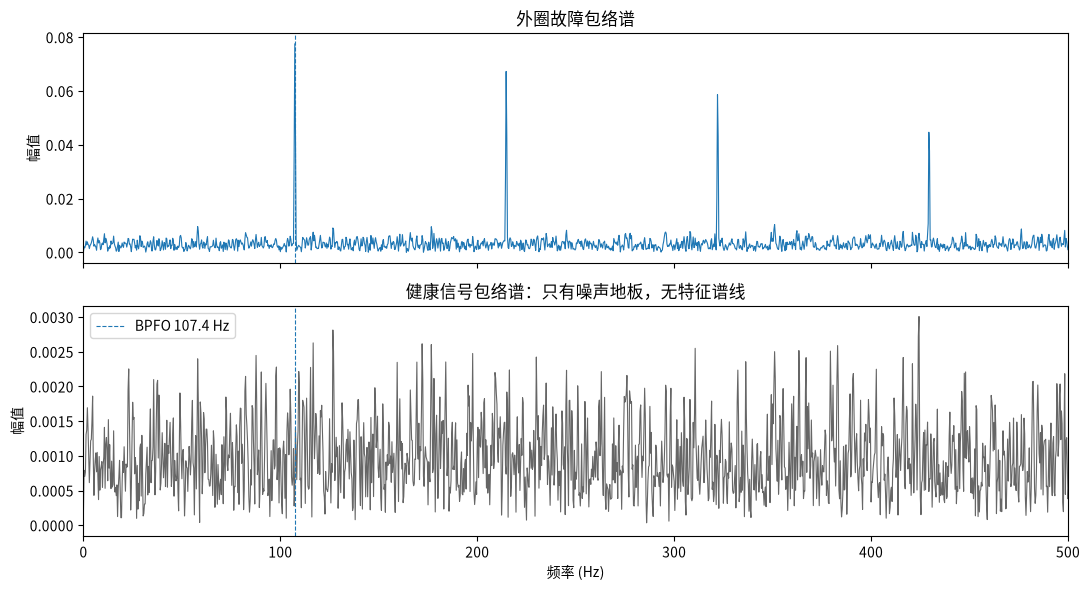

In [6]:
x_h = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal("healthy")
res_h = envelope_analysis(x_h, FS)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(env_freqs, env_amps, lw=0.8, color="tab:blue")
axes[0].axvline(BPFO, color="tab:blue", ls="--", lw=0.8)
axes[0].set_title("外圈故障包络谱")
axes[0].set_ylabel("幅值")
axes[1].plot(res_h["env_freqs"], res_h["env_amps"], lw=0.8, color="0.4")
axes[1].axvline(BPFO, color="tab:blue", ls="--", lw=0.8, label=f"BPFO {BPFO:.1f} Hz")
axes[1].set_title("健康信号包络谱：只有噪声地板，无特征谱线")
axes[1].set_xlabel("频率 (Hz)")
axes[1].set_ylabel("幅值")
axes[1].legend()
axes[1].set_xlim(0, 500)
fig.tight_layout()
plt.show()

**小结**：包络分析的四步——带通滤波 → Hilbert 取包络 → 去直流 → FFT——
把藏在高频共振里的故障重复频率"解调"到低频谱线上，是轴承故障诊断最核心的方法。
实际工程中频带选择可用谱峭度（kurtogram）辅助，本仿真信号用缺省频带即可。

→ 下一节：[04 阶次分析](04_order_analysis.ipynb)